# Tutorial3: Trajectory Inference using CellRank Pseudotime Kernel

## Introduction 
ATLAS is a multi-omics framework that supports trajectory inference on multi-omics data. ATLAS is build upon estimated TI tools for trajectory inference such as Palantir {cite}`palantir` and CellRank {cite}`cellrank2`. 

In this set of tutorials, you will learn how to: 
- Construct a multimodal container containing gene expression and gene activity data
- Perform trajectory inference using Palantir as underlying TI strategy
- Perform trajecotry inference unsing CellRank as underlying TI strategy
- Evaluate results from the trajectory inference 
- Perform multimodal plots 

Pseudotime values were generated in Tutorial 2. Data for this tutorial are available here or can be downloaded according to the following bash command:

In [1]:
!mkdir -p data && cd data

In this tutorial we analyze a multimodal SHARE-seq dataset of mouse hair follicle cells {cite}`shareseq`. 

The dataset includes `hair follicle stem cells` (HFSCs), `transit-amplifying cells` (TACs), and their differentiated progeny along multiple lineages, such as the `hair-shaft medulla`, the  `hair-shaft cuticle cortex` and the `inner root sheat`  (IRS), making it an ideal benchmark for multimodal trajectory inference.

The {class}`muon.MuData` object is already preprocessed and contains two modalities: `rna` with gene expression values and `activity` with gene activity values. Preprocessing followed similar computations as illustrated in Tutorial 1 and is available *at this link*. 

In [1]:
import os
import atlas
import muon as mu
import numpy as np
import pandas as pd


seed = 42
rng = np.random.default_rng(seed)
np.random.seed(seed)
n_states = 6


data_path = os.path.join(os.getcwd(), "data")
initial_data = mu.read_h5mu(os.path.join(data_path, "hair.h5mu"))
pseudotime = pd.read_csv(os.path.join(data_path, "pseudotime.csv"), header=None, index_col=0)
pseudotime.columns = ["pseudotime"]

initial_data.obs = initial_data.obs.merge(pseudotime, left_index=True, right_index=True, how="left")

/Users/lrcq/atlasVenv/lib/python3.12/site-packages/mudata/_core/mudata.py:931: UserWarning: Cannot join columns with the same name because var_names are intersecting.
  warnings.warn(


We now need to obtain the Weighted Nearest Neighbor (WNN) graph {cite}`wnn` as explained in Tutorial 1. We exploit ATLAS preprocessing function to create the WNN and UMAP. 

We already provided the `activity` modality, therefore we don't need to feed the preprocessing function with genomics coordinates or the fragments file path and we set these two options to `None`. The {func}`atlas.pp.preprocessing` computes single-modalities K-Nearest Neighbors (KNN) graphs, the WNN and the UMAP 2D visualization. 

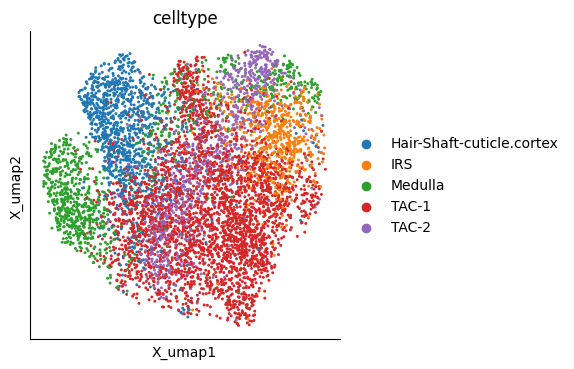

In [2]:
knn_rna, knn_act, wnn = 15, 15, None
n_pcs_rna, n_pcs_act = 20, 10

mudata = atlas.pp.preprocessing(
    mudata=initial_data,
    n_pcs_rna=n_pcs_rna,
    n_pcs_act=n_pcs_act,
    knn_rna=knn_rna,
    knn_act=knn_act,
    n_neighbors=wnn,
    features=None,
    fragment_path=None,
    random_state=seed,
)

mu.pl.embedding(mudata, basis="X_umap", color="celltype")

## Trajectory Inference Using ATLAS

This tutorial focuses on:
- Performing TI with ATLAS using `CellRank` as the underlying strategy.
- Visualizing the TI results.
- Perform multimodal visualisations
- Applying unsupervised metrics defined in ATLAS to assess the confidence of the inferred trajectory.


CellRank {cite}`cellrank2`, in its Pseudotime-Kernel implementation, orients the cell-cell graph using precomputed pseudotime values and then applies Generalized Perron Cluster Cluster Analysis (GPCCA) to the resulting manifold to identify macrostates. Its underlying assumption is that, during development, cell state changes are incremental: one expects to observe small, gradual transitions rather than abrupt jumps. Under this assumption, a K-nearest-neighbor (KNN) graph built on single-cell data is able to reconstruct a manifold that connects cells with similar expression states, thereby capturing cell state evolution.

ATLAS extends CellRank's capabilities to multi-omics data, based on the consideration that development is driven not only by gene expression, but also by the underlying regulatory mechanisms. Consequently, ATLAS TI (CellRank-based) generalizes the original assumption of incremental cell state changes to a manifold that incorporates complementary information about gene regulation.

From the perspective of this tutorial, ATLAS extends the CellRank Pseudotime Kernel to MuData objects through the {class}`~atlas.tl.CellRankExtension` class. The extended functionalities include:
- Computation of the transition matrix
- Schur decomposition of the dynamics
- Identification of macrostates using GPCCA
- Identification of initial, intermediate, and terminal macrostates, together with cell-fate probabilities

Mathematical details about CellRank are described in the original publication {cite}`cellrank1`.

In [3]:
cex = atlas.tl.CellRankExtension(mudata=mudata)
cex.compute_kernel(
    connectivity_key="wnn_connectivities", time_key="pseudotime", cluster_key="celltype", n_jobs=1, backend="threading"
)

cex.run(n_states=n_states, use_petsc=True, allow_overlap=False, backend="threading", n_jobs=1)

  0%|          | 0/6649 [00:00<?, ?cell/s]

  0%|          | 0/4 [00:00<?, ?/s]

{class}`~atlas.tl.CellRankExtension` accepts as input the multiomics instance and applies kernel computation. The {meth}`~atlas.tl.CellRankExtension.run` method computes pseudotime and cell-wise fate probabilites.

The multimodal object now stores additional results: 
- Two columns containing entropy measures are added to the `.obs` slot, namely `shannon_entropy` and `kl_divergence`. These are mesurements for cell plasticity. 
- `initial_states`, `intermediate_states` and `terminal_states` are added to the `.uns` slot. These dictionaries contain the list of identifies terminal, intermediate and initial states.
- `fate_state_colors` is added to the `.uns` slot.
- `fate_probabilities` is added to the `.obsm` slot. These are the cell fate probabilities towards the inferred branches. 

We will here use ATLAS plotting functions to visualize results form the TI process, such as the pseudotime, the entropy measures and the fate probability distribution over the UMAP embedding.

## Trajectory Inference Visualization

ATLAS provides plotting functions for the cell-fate probabilities and results from the TI. Specifically, ATLAS provides the following: 
- {func}`atlas.pl.plot_embedding` which plots obervations from the `.obs` slot onto and embedding (default is UMAP).
- {func}`atlas.pl.plot_fate_probabilities` which plots fate probabilities distributions as in {cite}`cellrank1` onto an embedding (default is UMAP).
- {func}`atlas.pl.plot_tree` which plots the developmental tree onto an embedding (default is UMAP) along with the developmental dendogram as performed by {cite}`scfates`.

Here we provide an example of the functions applied to the TI results: ATLAS recovers one initial macrostate and one intermediate state composed by "TAC" cells, whereas terminal states mostly correspond to expected developmental lineages. 

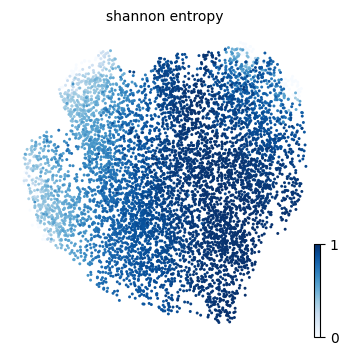

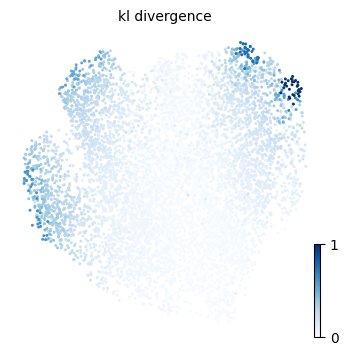

In [4]:
p1 = atlas.pl.plot_embedding(mudata, observation="shannon_entropy")
p2 = atlas.pl.plot_embedding(mudata, observation="kl_divergence")

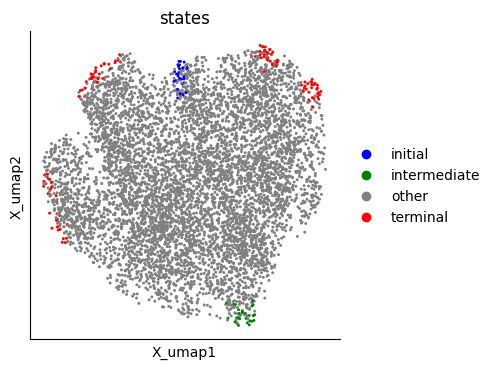

In [5]:
initial_states = mudata.uns["initial_states"]
intermediate_states = mudata.uns["intermediate_states"]
terminal_states = mudata.uns["terminal_states"]
mudata.obs["states"] = "other"
for _, cells in initial_states.items():
    mudata.obs.loc[cells, "states"] = "initial"
for _, cells in intermediate_states.items():
    mudata.obs.loc[cells, "states"] = "intermediate"
for _, cells in terminal_states.items():
    mudata.obs.loc[cells, "states"] = "terminal"

p2 = mu.pl.embedding(
    mudata,
    basis="X_umap",
    color="states",
    palette={"other": "grey", "initial": "blue", "terminal": "red", "intermediate": "green"},
)

In [6]:
print("INITIAL COMPOSITION:")
for k, cells in initial_states.items():
    print(f"\t{k}\n", mudata.obs.loc[cells, ["celltype"]].value_counts())

print("\n\n")

print("INTERMEDIATE COMPOSITION:")
for k, cells in intermediate_states.items():
    print(f"\t{k}\n", mudata.obs.loc[cells, ["celltype"]].value_counts())

INITIAL COMPOSITION:
	TAC-1_1
 celltype                 
TAC-1                        27
Medulla                       2
TAC-2                         1
Hair-Shaft-cuticle.cortex     0
IRS                           0
Name: count, dtype: int64



INTERMEDIATE COMPOSITION:
	TAC-1_2
 celltype                 
TAC-1                        30
Hair-Shaft-cuticle.cortex     0
IRS                           0
Medulla                       0
TAC-2                         0
Name: count, dtype: int64


In [7]:
print("TERMINAL COMPOSITION:")
for k, cells in terminal_states.items():
    print(f"\t{k}\n", mudata.obs.loc[cells, ["celltype"]].value_counts())

TERMINAL COMPOSITION:
	Medulla_1
 celltype                 
Medulla                      26
IRS                           4
Hair-Shaft-cuticle.cortex     0
TAC-1                         0
TAC-2                         0
Name: count, dtype: int64
	TAC-2
 celltype                 
TAC-2                        30
Hair-Shaft-cuticle.cortex     0
IRS                           0
Medulla                       0
TAC-1                         0
Name: count, dtype: int64
	Medulla_2
 celltype                 
Medulla                      30
Hair-Shaft-cuticle.cortex     0
IRS                           0
TAC-1                         0
TAC-2                         0
Name: count, dtype: int64
	Hair-Shaft-cuticle.cortex
 celltype                 
Hair-Shaft-cuticle.cortex    30
IRS                           0
Medulla                       0
TAC-1                         0
TAC-2                         0
Name: count, dtype: int64


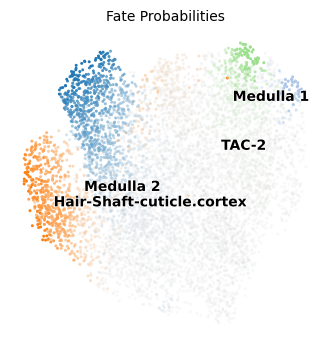

In [8]:
p1 = atlas.pl.plot_fate_probabilities(mudata)

Converting CellRank results to a principal tree --> with .obsm['X_fates'], created by combining:
    .obsm['X_fate_simplex_fwd'] (from cr.pl.circular_projection) and adata.obs['pseudotime']

inferring a principal tree --> parameters used 
    300 principal points, sigma = 0.1, lambda = 100, metric = euclidean
    fitting:  18%|█▊        | 9/50 [00:00<00:03, 12.95it/s]
    converged
    finished (0:00:00) --> added 
    .uns['ppt'], dictionnary containing inferred tree.
    .obsm['X_R'] soft assignment of cells to principal points.
    .uns['graph']['B'] adjacency matrix of the principal points.
    .uns['graph']['F'] coordinates of principal points in representation space.

finished (0:00:56)     .obsm['X_fates'] representation used for fitting the tree.
    .uns['graph']['pp_info'].time has been updated with pseudotime
    .uns['graph']['pp_seg'].d has been updated with pseudotime
node 236 selected as a root --> added
    .uns['graph']['root'] selected root.
    .uns['graph']['pp_info

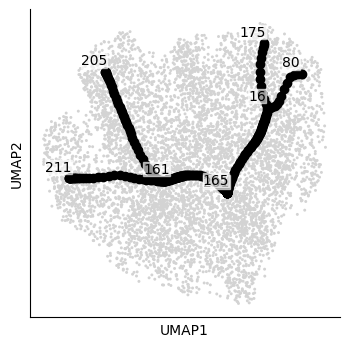

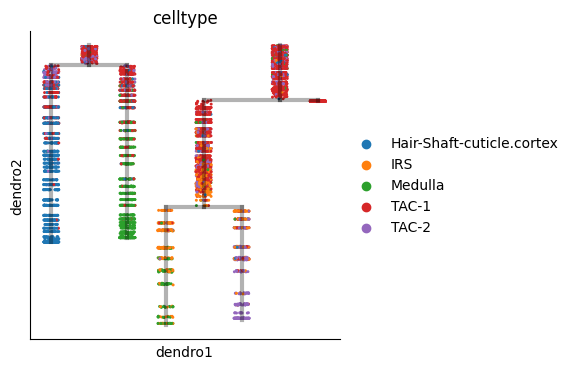

In [9]:
atlas.pl.plot_tree(mudata, color="celltype")

## Joint multi-omic visualization of regulatory programs

**Why multi-omic visualization matters?** Single-omic representations of differentiation only tell half of the story. Transcription factors (TFs) act on chromatin before their downstream targets are transcribed, so the temporal coupling between regulatory engagement and transcriptional output is itself a signal of how a regulatory program unfolds along a lineage.

ATLAS makes this coupling directly visible by jointly plotting, along each inferred branch, the expression of a TF together with the regulatory activity of a downstream target gene. The two signals share an axis — pseudotime — and a context — the same branch — so that temporal offsets, co-activation, and lineage specificity become apparent at a glance.

Looking at expression and activity together along the same lineage allows several questions to be addressed that neither modality can answer in isolation:

- Temporal ordering — does the regulator's chromatin context open before, with, or after the rise in TF expression? Lead-lag relationships are a hallmark of direct regulation.
- Lineage specificity — does a TF–target pair co-activate in one branch and not others? Branch-specific co-dynamics suggest lineage-defining regulatory modules, whereas pan-lineage co-activation suggests housekeeping or upstream programs.
- Decoupling events — sustained expression with declining activity (or vice versa) flags loss of coupling between transcription and regulation, often associated with cell-fate transitions.

Because differentiation in systems like the hair follicle proceeds gradually and asynchronously across lineages, these questions can only be addressed with a representation that is simultaneously temporal, branch-aware, and multi-omics.

To produce smooth, branch-specific trends that respect this uncertainty, ATLAS fits a Generalized Additive Model (GAM) independently for each branch $t$ and each signal $s$ (TF expression or target activity), where fate probabilities weight each cell's contribution to its branch, while the curvature penalty enforces smoothness. 

For example, the figure shows `Lef1` expression (top) and `Prdm1` regulatory activity (bottom) along pseudotime, with one smoothed trend per lineage. Three patterns stand out:

- Lef1 expression is sharply lineage-restricted, as it rises strongly and monotonically along the HS-cortex branch. This is consistent with Lef1's established role as a key driver of hair-shaft differentiation downstream of Wnt signaling.
- Prdm1 activity shows coordinated but lineage-graded engagement: activity of Prdm1 rises along the same two branches where Lef1 expression rises — HS-cortex and Medulla2. The two signals are therefore co-activated on the lineages where activation is expected, supporting a regulatory link between Lef1 and Prdm1 in this system.
- Lead-lag dynamics differ between branches: on the HS branch, Lef1 expression climbs early and steeply while Prdm1 activity rises more gradually and plateaus — the pattern of a TF whose transcriptional output anticipates and sustains downstream regulatory engagement. On the Medulla2 branch the opposite is true: Lef1 levels off in the second half of pseudotime, while Prdm1 activity continues to climb, reaching its highest values late in the trajectory.

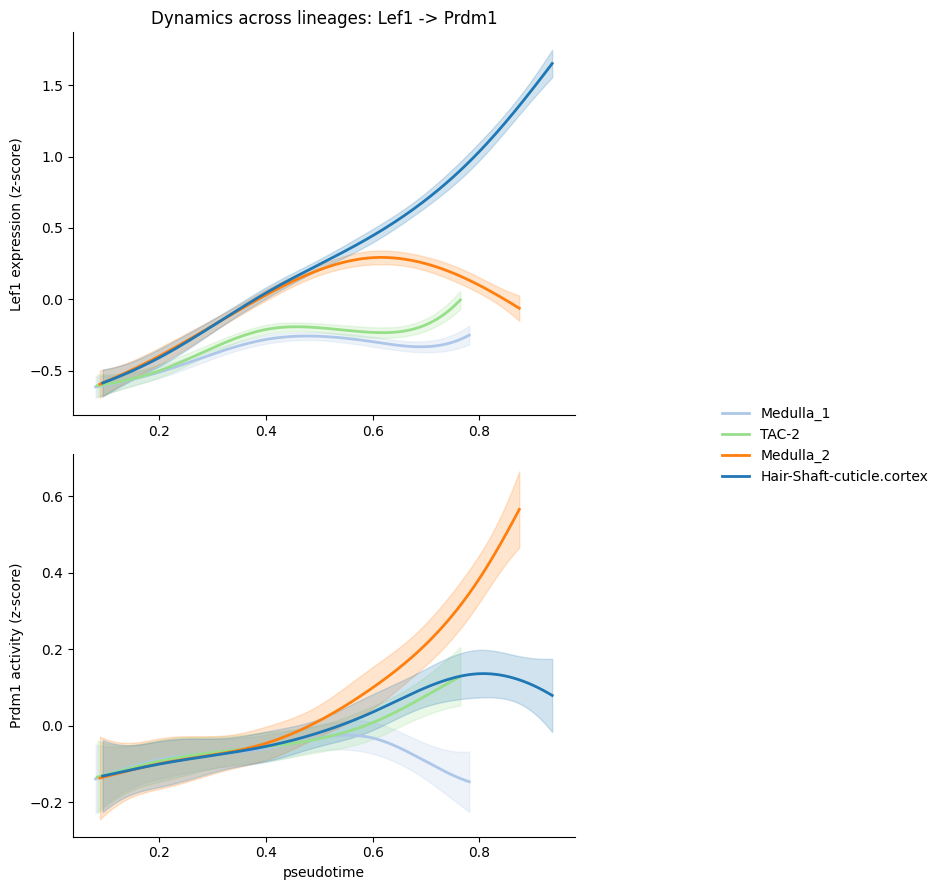

In [10]:
atlas.pl.plot_trends(mudata, ptf="Lef1", gene="Prdm1")

## Unsupervised evaluation of trajectory inference

So far we have inferred initial, terminal and intermediate states together with cell-wise fate probabilities. A natural follow-up question is: **are these results meaningful?**

ATLAS provides a set of unsupervised metrics that do not require ground-truth annotations and instead assess the internal consistency of the inferred trajectory. Such metrics evaluate three complementary aspects of fate inference:

1. **Coupling between fate concentration and pseudotime** — do cells become more committed as differentiation progresses?
2. **Relationship between fate uncertainty and differentiation progress** — does entropy decrease over pseudotime?
3. **Separation and coherence of inferred terminal states** — are terminal states well-resolved in fate probability space?

In the following we apply each metric to the SHARE-seq dataset TI results.

- `Entropy along pseudotime`: if fate inference reflects a meaningful loss of plasticity along differentiation, cell-wise fate entropy should correlate with pseudotime. ATLAS quantifies this with both Pearson (linear) and Spearman (rank-based, monotonic) correlation between pseudotime and entropy.
- `Fate Concentration Index (FCI)`: measures how fate probability mass concentrates on a few terminal states as differentiation proceeds. Concentration $\lambda$ is quantified with the [Simpson index](https://en.wikipedia.org/wiki/Diversity_index). The FCI is then defined as the Spearman correlation between pseudotime and $\lambda$. 
- `Terminal Pseudotime Enrichment Score (TPES)`: assesses whether inferred terminal states are enriched for late-pseudotime cells. For each terminal state $t$ it measures the shift of its pseudotime distribution relative to the global one, and averages across all terminal states. Terminal states are enriched for *late-pseudotime* cell provide positive values for this metric, where negative values are btained when terminal states are associated to early-pseudotime values. A rank-based variant replaces pseudotime values with their normalized ranks, making the score invariant to monotonic transformations of pseudotime and thus suitable for cross-method comparisons.
- `Terminal State Silhouette (S)`: quantifies how clearly terminal states emerge as distinct endpoints in fate probability space. This metric operates on the model's own outputs, directly evaluating the resolution of inferred terminal outcomes. ATLAS provides two extensions: (1) **Pseudotime-weighted silhouette**, as early multipotent cells naturally have diffuse fate probabilities S if weighted weighting by pseudotime and  emphasizes late-stage resolution; (2) **Soft silhouette** , avoids the artificial hard fate assignment by weighting intra- and inter-terminal distances by the probability that two cells share a fate, preserving uncertainty information.


In [11]:
pstat, ppval, pci = atlas.tl.pearson_correlation(mudata, key1="pseudotime", key2="shannon_entropy", seed=seed)
sstat, spval, sci = atlas.tl.spearman_correlation(mudata, key1="pseudotime", key2="shannon_entropy", seed=seed)
fci, pval_fci, ci_fci, _ = atlas.tl.fate_concentration_index(mudata, seed=seed)
tpes = atlas.tl.terminal_pseudotime_enrichment(mudata, rank=True)
spse = atlas.tl.terminal_state_silhouette(mudata, soft_assignment=False, time_key="pseudotime")
ssoft = atlas.tl.terminal_state_silhouette(mudata, soft_assignment=True)

In [12]:
results = {
    "Statistics": [pstat, sstat, fci, tpes, spse, ssoft],
    "Pval": [ppval, spval, pval_fci, None, None, None],
    "ci_lower": [pci[0], sci[0], ci_fci[0], None, None, None],
    "ci_upper": [pci[1], sci[1], ci_fci[1], None, None, None],
}
results = pd.DataFrame(
    results,
    index=[
        "PearsonR pseudotime - entropy",
        "SpearmanR pseudotime-entropy",
        "Fate Concentration Index",
        "TPES",
        "S pseudotime",
        "S Soft",
    ],
)
results["95% CI"] = results.apply(
    lambda r: f"({r['ci_lower']:.3f}; {r['ci_upper']:.3f})" if pd.notna(r["ci_lower"]) else np.nan, axis=1
)
print(results.to_string(float_format="{:.3f}".format, na_rep="-"))

                               Statistics  Pval  ci_lower  ci_upper            95% CI
PearsonR pseudotime - entropy      -0.825 0.000    -0.833    -0.818  (-0.833; -0.818)
SpearmanR pseudotime-entropy       -0.844 0.000    -0.852    -0.835  (-0.852; -0.835)
Fate Concentration Index            0.853 0.000     0.844     0.861    (0.844; 0.861)
TPES                                0.444     -         -         -                 -
S pseudotime                        0.393     -         -         -                 -
S Soft                              0.108     -         -         -                 -


The metrics show a strong coupling between the inferred trajectory and pseudotime, good terminal state recovery and fate- concentration along pseudotime:
- Entropy and pseudotime are tightly anti-correlated (Pearson $r = -0.825$, Spearman $\rho = -0.844$): the two coefficients agree closely, indicating that the entropy–pseudotime relationship is essentially monotonic and well captured by a linear model. Cells progressively lose fate uncertainty as they advance along pseudotime, consistent with a gradual commitment process.
- Fate Concentration Index ($\rho = 0.853$): fate probability mass concentrates on a small subset of terminal states as differentiation proceeds. Together with the entropy correlation, this provides strong evidence that the inferred fate probabilities encode a biologically coherent commitment trajectory.
- TPES: 0.444 (rank based) confirms that inferred terminal states are enriched for late-pseudotime cells, with a substantial positive shift relative to the global pseudotime median.
- Silhouette S: the pseudotime-weighted hard silhouette ($S = 0.393$) indicates moderate but not sharp separation between terminal outcomes in fate probability space — the inferred fates are distinguishable, but with some overlap. The soft silhouette is markedly lower ($S = 0.108$), reflecting the substantial fate uncertainty retained by many cells once the hard $\arg\max$ assignment is replaced by the full probability distribution. This is biologically plausible for the hair follicle system, where transit-amplifying cells and early progenitors are known to retain multipotency for an extended portion of the differentiation process before committing to a specific lineage (e.g., IRS vs. hair shaft).

Overall, the unsupervised metrics support the inferred trajectory: pseudotime, entropy and fate concentration are coherently coupled, and terminal states are well localized at the end of the differentiation process. The lower soft silhouette is consistent with the biology of the system rather than indicative of a failure of the inference.